In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

In [3]:
df['X1'] = [1,2,3,4,5,6,7,8,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,7,5,0
7,8,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

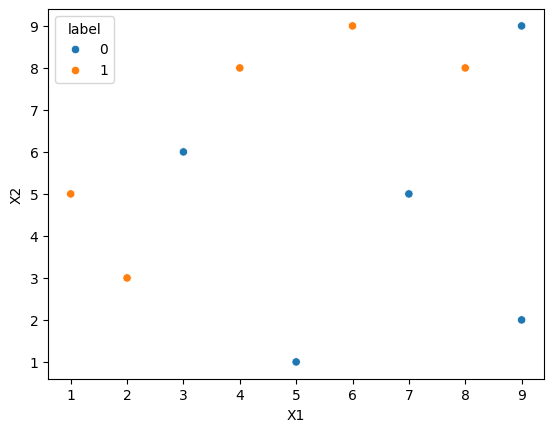

In [5]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [6]:
df['weights'] = 1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier

dt1= DecisionTreeClassifier(max_depth=1)


In [9]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [10]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

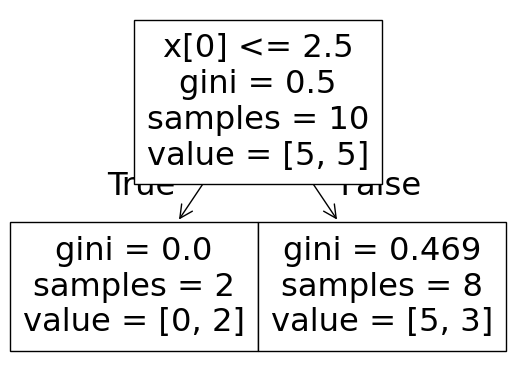

In [11]:
from sklearn.tree import plot_tree

plot_tree(dt1)

<Axes: >

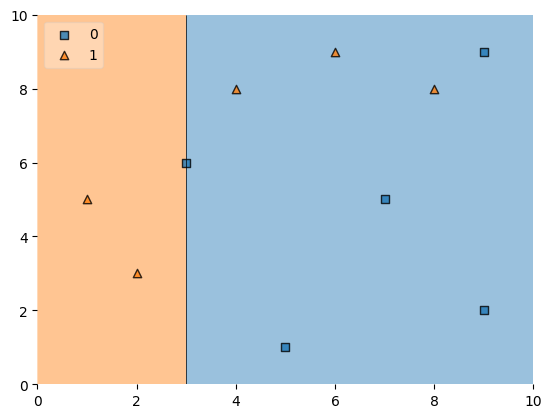

In [12]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [13]:
df['y_pred'] = dt1.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,7,5,0,0.1,0
7,8,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [45]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error+0.00000001))

In [15]:
#Step-3 : calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [16]:
#Step-4 : Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [17]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [18]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,7,5,0,0.1,0,0.065508
7,8,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [19]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [20]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [21]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,7,5,0,0.1,0,0.065508,0.071475
7,8,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [22]:
df['normalized_weights'].sum()

np.float64(1.0)

In [23]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [25]:
df.columns

Index(['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights',
       'normalized_weights', 'cumsum_upper', 'cumsum_lower'],
      dtype='object')

In [27]:
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights',
       'normalized_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.071475,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.166559,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.166559,0.452458,0.619017
6,7,5,0,0.1,0,0.065508,0.071475,0.619017,0.690492
7,8,8,1,0.1,0,0.152653,0.166559,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.071475,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,0.928525,1.000000


In [32]:
#Up-sampling
def create_new_dataset(df):
  indices =[]
  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [33]:
index_values = create_new_dataset(df)
index_values

[5, 7, 8, 7, 3, 7, 8, 5, 3, 9]

In [35]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [36]:
second_df

,X1,X2,label,weights
5,6,9,1,0.1
7,8,8,1,0.1
8,9,9,0,0.1
7,8,8,1,0.1
3,4,8,1,0.1
7,8,8,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
3,4,8,1,0.1
9,9,2,0,0.1


In [37]:
dt2= DecisionTreeClassifier(max_depth=1)

In [38]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [39]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.5\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

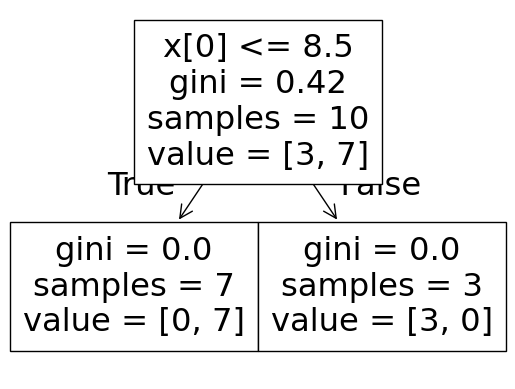

In [40]:
plot_tree(dt2)

<Axes: >

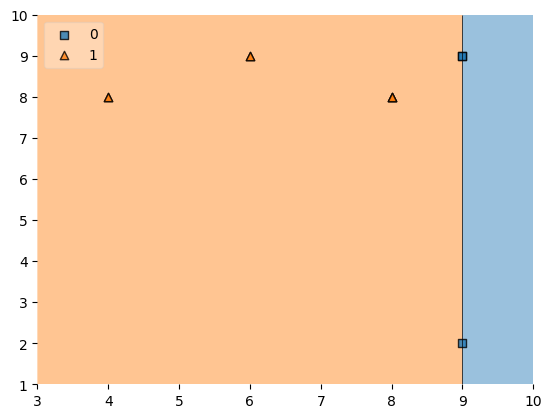

In [41]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [42]:
second_df['y_pred'] = dt2.predict(X)
second_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
7,8,8,1,0.1,1
8,9,9,0,0.1,0
7,8,8,1,0.1,1
3,4,8,1,0.1,1
7,8,8,1,0.1,1
8,9,9,0,0.1,0
5,6,9,1,0.1,1
3,4,8,1,0.1,1
9,9,2,0,0.1,0


In [46]:
alpha2 = calculate_model_weight(0)
alpha2

np.float64(9.210340371976184)

In [47]:
def update_row_weights(row,alpha=9.210340371976184):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [48]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
second_df

,X1,X2,label,weights,y_pred,updated_weights
5,6,9,1,0.1,1,0.00001
7,8,8,1,0.1,1,0.00001
8,9,9,0,0.1,0,0.00001
7,8,8,1,0.1,1,0.00001
3,4,8,1,0.1,1,0.00001
7,8,8,1,0.1,1,0.00001
8,9,9,0,0.1,0,0.00001
5,6,9,1,0.1,1,0.00001
3,4,8,1,0.1,1,0.00001
9,9,2,0,0.1,0,0.00001


In [50]:
second_df['updated_weights'].sum()

np.float64(9.999999999999994e-05)

In [51]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [52]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
5,6,9,1,0.1,1,0.00001,0.1
7,8,8,1,0.1,1,0.00001,0.1
8,9,9,0,0.1,0,0.00001,0.1
7,8,8,1,0.1,1,0.00001,0.1
3,4,8,1,0.1,1,0.00001,0.1
7,8,8,1,0.1,1,0.00001,0.1
8,9,9,0,0.1,0,0.00001,0.1
5,6,9,1,0.1,1,0.00001,0.1
3,4,8,1,0.1,1,0.00001,0.1
9,9,2,0,0.1,0,0.00001,0.1


In [54]:
second_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [55]:
print(alpha1,alpha2)

0.42364893019360184 9.210340371976184


In [56]:
#Prediction
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [57]:
dt2.predict(query)

array([1])

In [58]:
alpha1*(1) + alpha2*(1)

np.float64(9.633989302169786)

In [59]:
np.sign(alpha1*(1) + alpha2*(1))

np.float64(1.0)